In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np 

In [2]:
df = pd.read_csv("AirPassengers.csv")

In [3]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        144 non-null    str  
 1   #Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [5]:
df["Month"] = pd.to_datetime(df["Month"])

In [6]:
df['Month']

0     1949-01-01
1     1949-02-01
2     1949-03-01
3     1949-04-01
4     1949-05-01
         ...    
139   1960-08-01
140   1960-09-01
141   1960-10-01
142   1960-11-01
143   1960-12-01
Name: Month, Length: 144, dtype: datetime64[us]

In [7]:
df.set_index('Month',inplace=True)

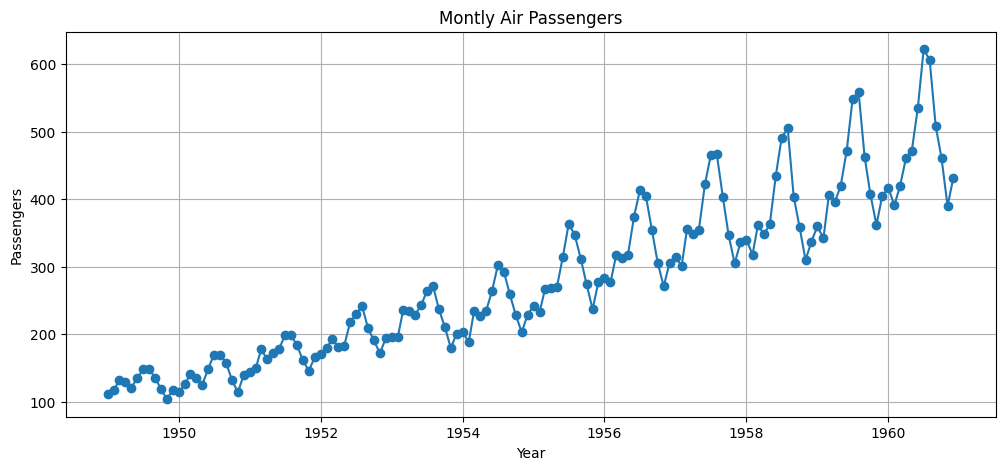

In [8]:
plt.figure(figsize=(12,5))

plt.plot(df['#Passengers'],marker='o')

plt.title('Montly Air Passengers')

plt.xlabel('Year')

plt.ylabel('Passengers')

plt.grid(True)

plt.show()

In [9]:
result = adfuller(df['#Passengers'])

print('ADF Statistic',result[0])
print('p-value:', result[1])

ADF Statistic 0.8153688792060482
p-value: 0.991880243437641


In [10]:
if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

Non-Stationary


In [11]:
df['Passengers_diff'] = df['#Passengers'].diff()

df_diff = df['Passengers_diff'].dropna()

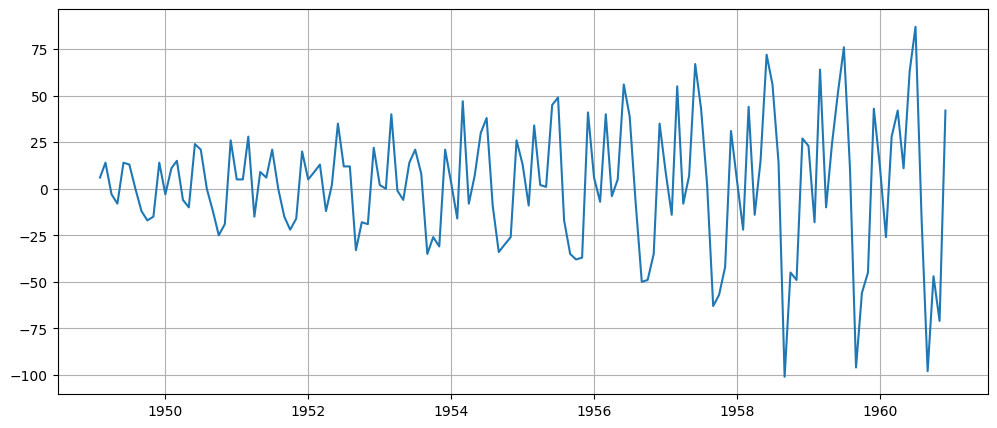

In [15]:
plt.figure(figsize=(12,5))

plt.plot(df_diff)
plt.grid(True)

plt.show()

In [12]:
result = adfuller(df_diff)
print(result[1])

0.0542132902838255


In [13]:
if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

Non-Stationary


In [14]:
df['Passengers_diff2'] = df_diff.diff()

df_diff2 = df['Passengers_diff2'].dropna()

In [15]:
result = adfuller(df_diff2)
print(result[1])

2.7328918500142407e-29


In [16]:
if result[1] < 0.05:
    print("Stationary")
else:
    print("Non-Stationary")

Stationary


Plot PACF (Choose p)

<Figure size 800x400 with 0 Axes>

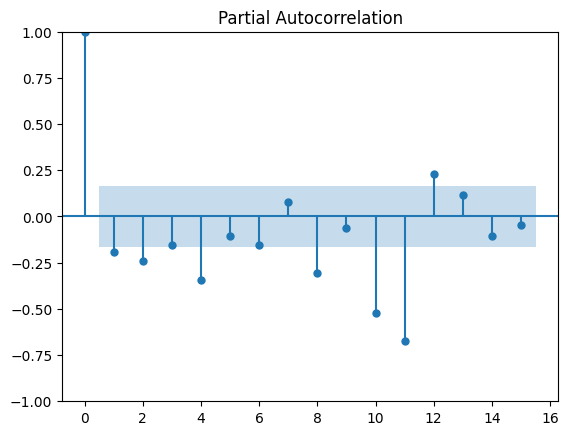

In [17]:
from statsmodels.graphics.tsaplots import plot_pacf 
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plot_pacf(df_diff2,lags=15)

plt.show()

<Figure size 800x400 with 0 Axes>

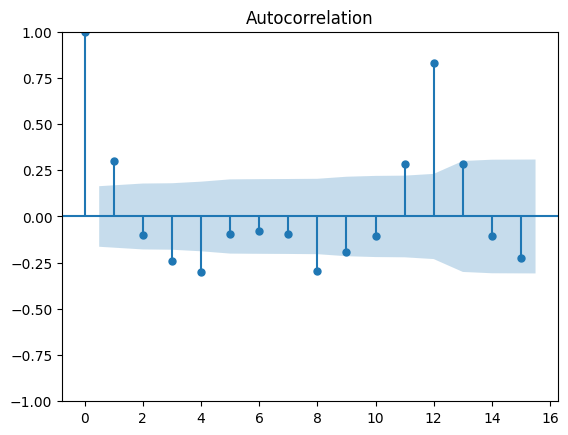

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,4))

plot_acf(df_diff,lags=15)

plt.show()

In [19]:
train = df.iloc[:-12]
test = df.iloc[-12:]

In [21]:
model = ARIMA(train["#Passengers"], order=(1,2,1))

model_fit = model.fit()

c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [22]:
forecast = model_fit.forecast(steps=len(test))

In [23]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test["#Passengers"], forecast)

print("MAE:", mae)

MAE: 59.7487302050986


In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test["#Passengers"], forecast))

print("RMSE:", rmse)

RMSE: 82.70492371261005


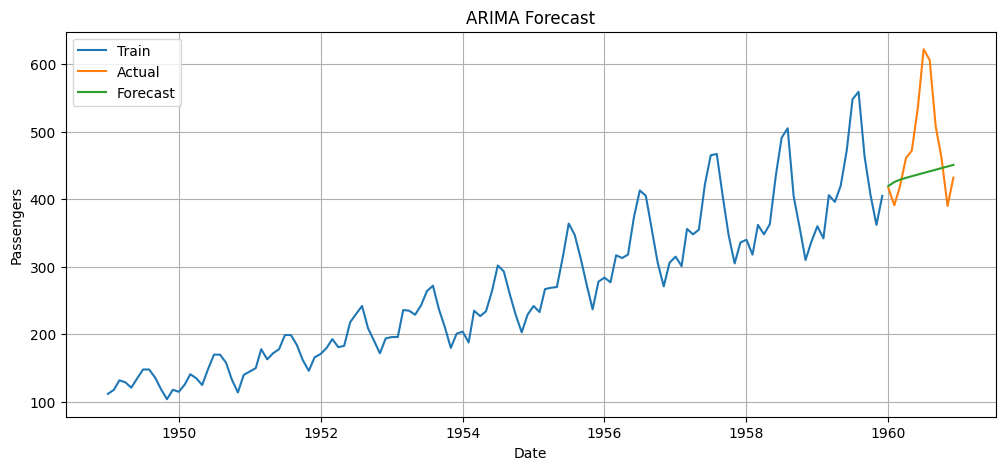

In [28]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train["#Passengers"], label="Train")
plt.plot(test.index, test["#Passengers"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.legend()
plt.grid(True)

plt.show()